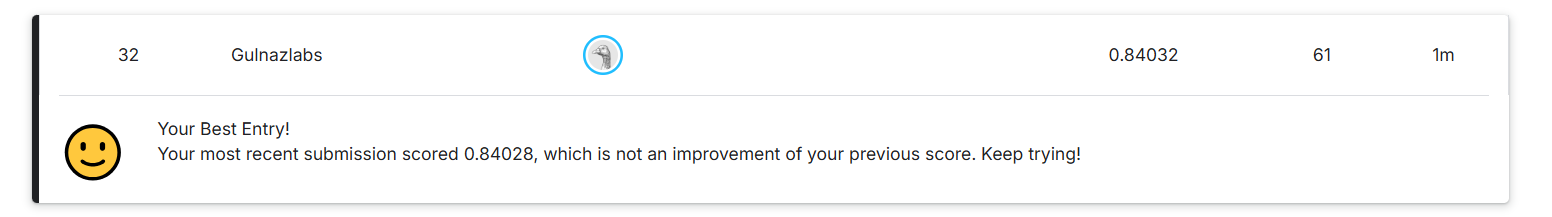

In [2]:
!pip install kagglehub

In [3]:
import kagglehub

path = kagglehub.competition_download(
    "signal-types-classification"
)

print("Путь к файлам:", path)

100%|██████████| 13.2M/13.2M [00:00<00:00, 58.4MB/s]

Extracting files...


Путь к файлам: /root/.cache/kagglehub/competitions/signal-types-classification


In [4]:
import os

os.listdir(path)

['Description.pdf', 'test-dataset.ipynb', 'Run200_Wave_0_1.txt']

In [5]:
# Импорт библиотек

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


In [6]:
file_path = os.path.join(path, "Run200_Wave_0_1.txt")

df = pd.read_csv(
    file_path,
    sep=" ",
    header=None,
    skipinitialspace=True
)

print(df.shape)

display(df.head())

df.info()

(23479, 505)


,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14822,14815,14815,14817,14819,14820,14822,14820,14819,NaN
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14817,14824,14822,14824,14819,14820,14819,14822,14820,NaN
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14821,14820,14820,14818,14821,14823,14820,14820,14821,NaN
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14826,14822,14821,14820,14828,14820,14822,14823,14822,NaN
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14823,14828,14824,14820,14824,14824,14822,14825,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 505 entries, 0 to 504
dtypes: float64(1), int64(504)
memory usage: 90.5 MB


Исходный датасет содержит 23 479 объектов и 505 признаков.

Первые четыре столбца являются метаданными и не описывают форму сигнала, поэтому они были исключены из дальнейшего анализа.  
Также последний столбец содержит пустые значения, поэтому он был удалён.

После удаления служебных и некорректных столбцов в датасете остались только временные отсчёты сигналов, которые я буду далее использовать для EDA, предобработки, извлечения признаков и кластеризации.

In [7]:
# Data loading
dataset = pd.read_csv(os.path.join(path, 'Run200_Wave_0_1.txt'),
                      sep=' ',
                      header=None,
                      skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


In [8]:
# EDA

print("Размер датасета:", dataset.shape)
print("Количество сигналов:", dataset.shape[0])
print("Количество временных отсчетов:", dataset.shape[1])

print("\nПропуски:", dataset.isnull().sum().sum())
print("Дубликаты:", dataset.duplicated().sum())

display(dataset.describe().T.head())

Размер датасета: (23479, 500)
Количество сигналов: 23479
Количество временных отсчетов: 500

Пропуски: 0
Дубликаты: 0


,count,mean,std,min,25%,50%,75%,max
0,23479.0,14822.972316,2.805884,14812.0,14821.0,14823.0,14824.0,14834.0
1,23479.0,14822.958474,2.833516,14812.0,14821.0,14823.0,14824.0,14835.0
2,23479.0,14822.970016,2.840755,14812.0,14821.0,14823.0,14825.0,14834.0
3,23479.0,14822.989991,2.852066,14811.0,14821.0,14823.0,14825.0,14835.0
4,23479.0,14823.003961,2.833412,14812.0,14821.0,14823.0,14825.0,14834.0


Text(0, 0.5, 'bit ADC')

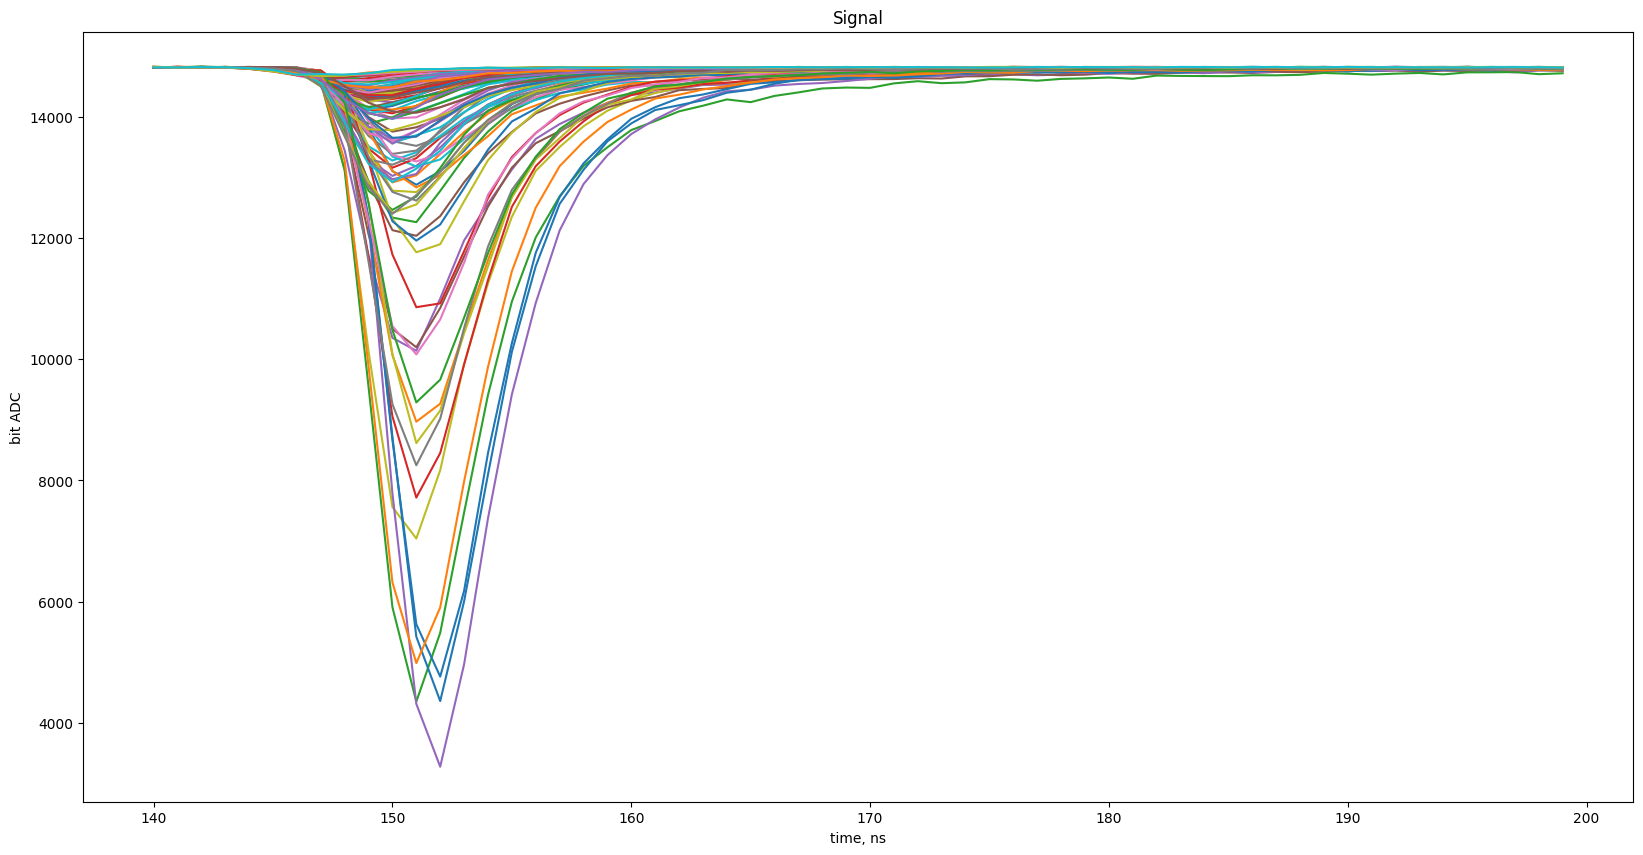

In [9]:
N=range(0,100)
ax = dataset.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

На графике видно, что основные импульсы сигналов расположены примерно в области 150-155 нс и имеют отрицательную форму относительно базовой линии. Сигналы различаются по амплитуде и форме хвоста, что может быть полезно для последующей кластеризации. Поэтому на следующем этапе требуется выполнить baseline correction и инверсию сигнала.

Text(0, 0.5, 'bit ADC')

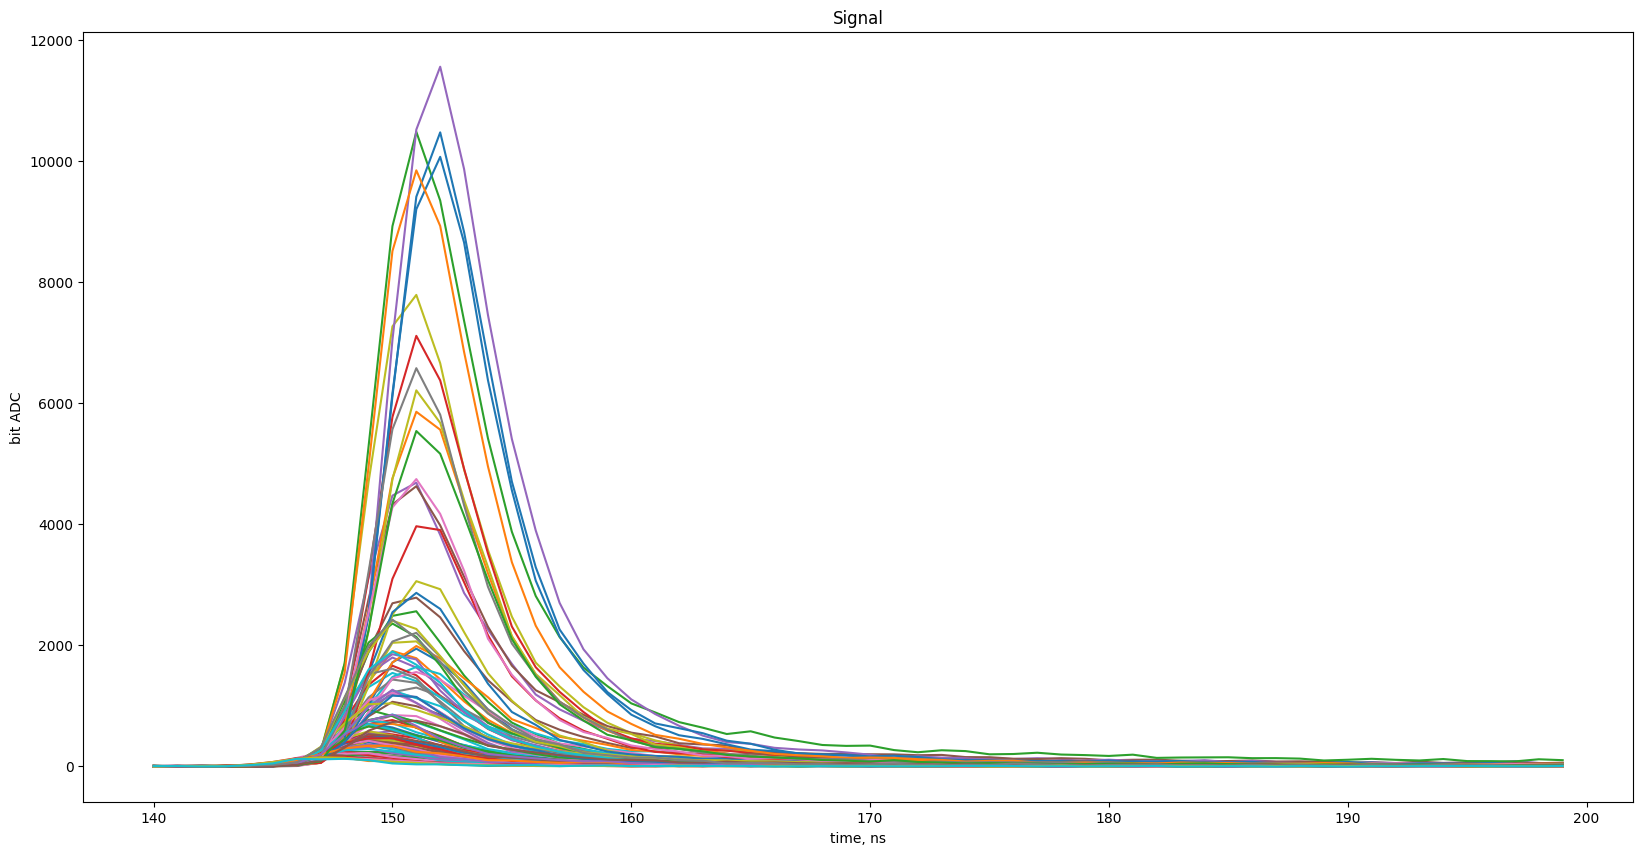

In [10]:
# Инверсия сигналов и приведение импульсов к положительной форме

ax = (2**14-dataset.T[N]-1560)[140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

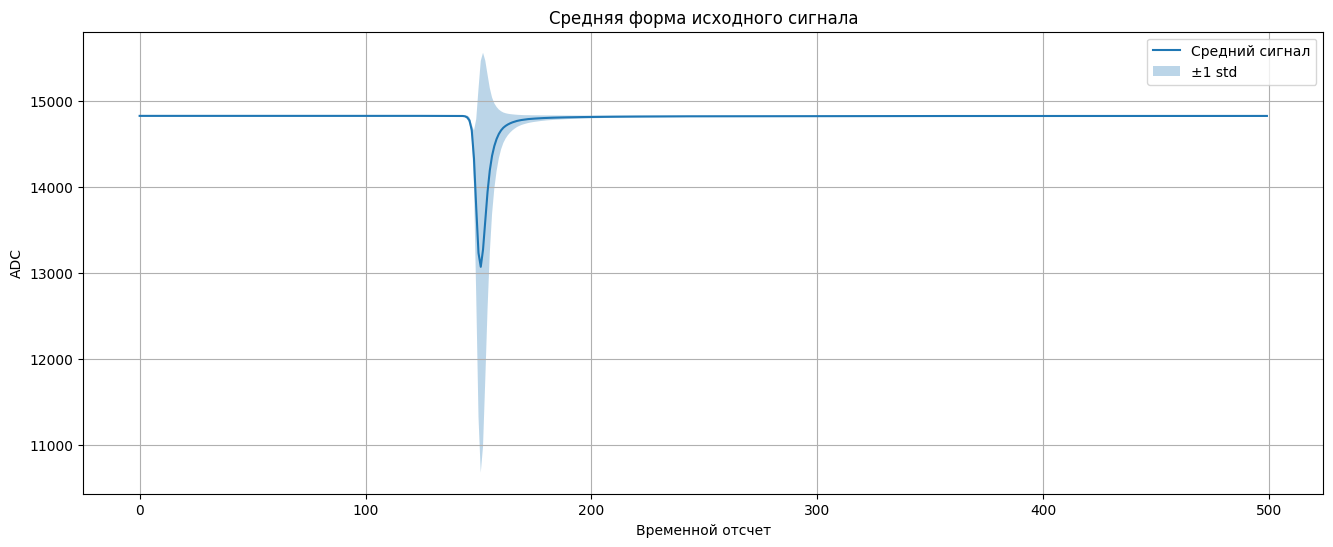

In [11]:
# Средняя форма сигнала и разброс значений

x_axis = np.arange(dataset.shape[1])

mean_signal = dataset.mean(axis=0).values
std_signal = dataset.std(axis=0).values

plt.figure(figsize=(16, 6))

plt.plot(x_axis, mean_signal, label="Средний сигнал")
plt.fill_between(
    x_axis,
    mean_signal - std_signal,
    mean_signal + std_signal,
    alpha=0.3,
    label="±1 std"
)

plt.title("Средняя форма исходного сигнала")
plt.xlabel("Временной отсчет")
plt.ylabel("ADC")
plt.legend()
plt.grid(True)
plt.show()

На графике представлена средняя форма исходного сигнала по всем объектам датасета, а также область разброса значений в пределах одного стандартного отклонения.

Видно, что до появления импульса сигнал находится около стабильного базового уровня. Основной импульс расположен примерно в области 145-160 временного отсчёта и имеет отрицательную форму, то есть значение ADC резко уменьшается относительно baseline.

Наибольший разброс наблюдается именно в области импульса. Это означает, что сигналы заметно различаются по амплитуде и форме восстановления после пика. Эти различия могут быть полезны для последующей кластеризации.

Полученный график подтверждает необходимость предобработки: коррекции базовой линии и инверсии сигнала, чтобы импульсы стали положительными и их признаки было удобнее рассчитывать.

In [12]:
# Baseline correction + инверсия сигнала
signals_raw = dataset.copy()

baseline_window = list(range(0, 100))

baseline = signals_raw.iloc[:, baseline_window].mean(axis=1)

signals_processed = -(signals_raw.sub(baseline, axis=0))

display(signals_processed.head())

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,1.13,-1.87,-2.87,-0.87,3.13,1.13,-2.87,-0.87,1.13,1.13,...,-6.87,-0.87,6.13,6.13,4.13,2.13,1.13,-0.87,1.13,2.13
1,2.47,0.47,2.47,-3.53,-1.53,0.47,2.47,0.47,-0.53,1.47,...,-5.53,5.47,-1.53,0.47,-1.53,3.47,2.47,3.47,0.47,2.47
2,1.92,1.92,-0.08,-3.08,1.92,-2.08,-2.08,2.92,-1.08,-2.08,...,1.92,0.92,1.92,1.92,3.92,0.92,-1.08,1.92,1.92,0.92
3,-5.24,0.76,4.76,-1.24,-1.24,0.76,2.76,0.76,-1.24,2.76,...,-1.24,-3.24,0.76,1.76,2.76,-5.24,2.76,0.76,-0.24,0.76
4,-1.57,6.43,-1.57,0.43,-5.57,1.43,-1.57,-2.57,5.43,0.43,...,1.43,1.43,-1.57,-6.57,-2.57,1.43,-2.57,-2.57,-0.57,-3.57


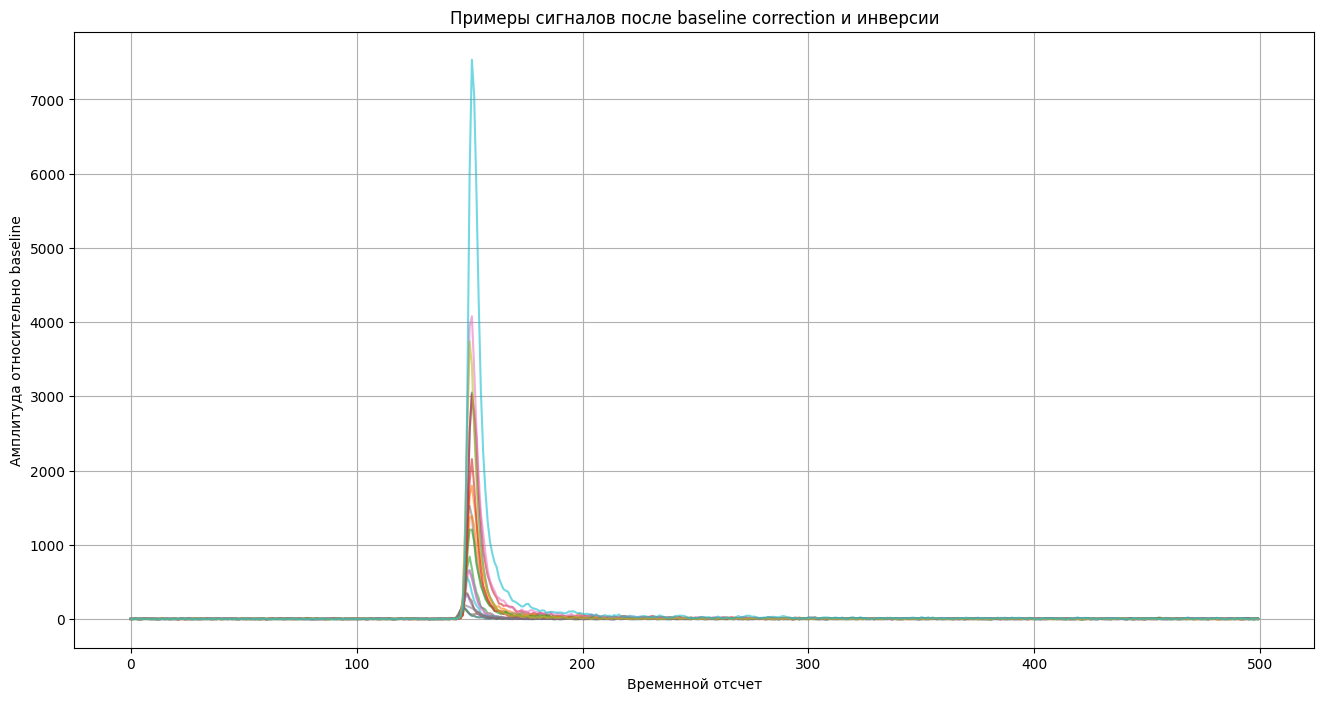

In [13]:
# Визуальная проверка предобработанных сигналов

random_indices = np.random.choice(signals_processed.index, size=20, replace=False)

plt.figure(figsize=(16, 8))

for idx in random_indices:
    plt.plot(x_axis, signals_processed.loc[idx].values, alpha=0.6)

plt.title("Примеры сигналов после baseline correction и инверсии")
plt.xlabel("Временной отсчет")
plt.ylabel("Амплитуда относительно baseline")
plt.grid(True)
plt.show()

После предобработки импульсы стали положительными и располагаются примерно в одной временной области.  
Основной пик большинства сигналов находится около 150 временного отсчёта.

Сигналы различаются по амплитуде и форме хвоста после пика. Эти различия важны для дальнейшего анализа, так как они могут отражать разные типы частиц или аномальные события.

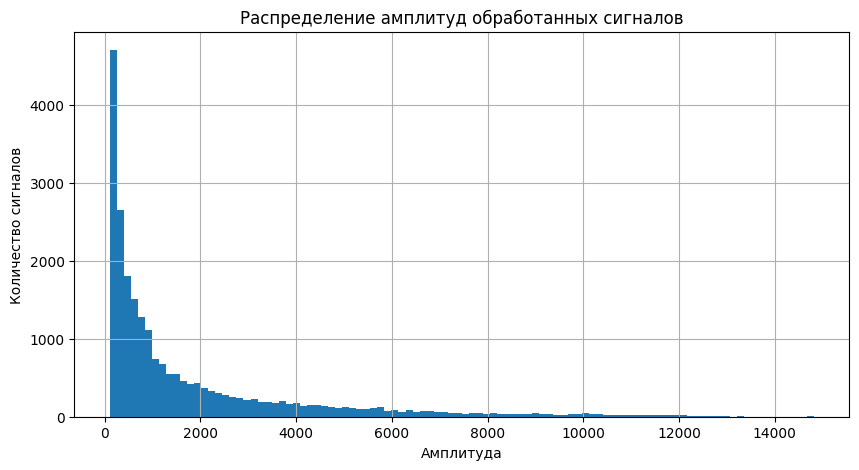

,0
count,23479.000000
mean,1835.103314
std,2389.301353
min,104.230000
25%,308.220000
50%,812.720000
75%,2315.270000
max,14824.820000


In [14]:
# Распределение амплитуд после предобработки

amplitudes = signals_processed.max(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(amplitudes, bins=100)
plt.title("Распределение амплитуд обработанных сигналов")
plt.xlabel("Амплитуда")
plt.ylabel("Количество сигналов")
plt.grid(True)
plt.show()

display(amplitudes.describe())

Распределение амплитуд имеет выраженную правостороннюю асимметрию: большинство сигналов имеют относительно небольшую амплитуду, при этом присутствуют сигналы с очень большими значениями амплитуды.

Медианная амплитуда заметно ниже среднего значения, что также указывает на наличие длинного правого хвоста распределения.  
Такая структура данных говорит о том, что при дальнейшем моделировании желательно использовать признаки формы сигнала и масштабирование, устойчивое к выбросам.

In [15]:
# Feature Engineering
# На этом этапе из временного ряда извлекаются числовые признаки, которые описывают амплитуду, площадь импульса, положение максимума и форму хвостовой части сигнала

signals = signals_processed.copy()

features = pd.DataFrame(index=signals.index)

eps = 1e-9

# Базовые статистики
features["amplitude"] = signals.max(axis=1)
features["min_value"] = signals.min(axis=1)
features["mean"] = signals.mean(axis=1)
features["std"] = signals.std(axis=1)

# Положение максимума
features["peak_pos"] = signals.values.argmax(axis=1)

# Интегралы
features["total_integral"] = signals.sum(axis=1)

# Области сигнала выбраны по результатам EDA: основной пик находится примерно около 145-160 отсчета
features["pre_peak_integral"] = signals.iloc[:, 120:145].sum(axis=1)
features["peak_integral"] = signals.iloc[:, 145:160].sum(axis=1)
features["fast_integral"] = signals.iloc[:, 145:170].sum(axis=1)
features["tail_integral"] = signals.iloc[:, 170:230].sum(axis=1)
features["long_tail_integral"] = signals.iloc[:, 230:350].sum(axis=1)

# PSD-признаки
features["tail_to_total"] = features["tail_integral"] / (features["total_integral"] + eps)
features["fast_to_total"] = features["fast_integral"] / (features["total_integral"] + eps)
features["tail_to_fast"] = features["tail_integral"] / (features["fast_integral"] + eps)
features["peak_to_total"] = features["peak_integral"] / (features["total_integral"] + eps)

# Дополнительные признаки формы
features["integral_to_amplitude"] = features["total_integral"] / (features["amplitude"] + eps)
features["tail_to_amplitude"] = features["tail_integral"] / (features["amplitude"] + eps)

# Признаки поздней активности для анализа возможных аномалий
late_window = signals.iloc[:, 430:500]

features["late_max"] = late_window.max(axis=1)
features["late_integral"] = late_window.sum(axis=1)
features["late_max_to_amplitude"] = features["late_max"] / (features["amplitude"] + eps)
features["late_integral_to_total"] = features["late_integral"] / (features["total_integral"] + eps)

# Обработка возможных inf/nan
features = features.replace([np.inf, -np.inf], np.nan)
features = features.fillna(features.median())

print("Размер таблицы признаков:", features.shape)
display(features.head())

Размер таблицы признаков: (23479, 21)


,amplitude,min_value,mean,std,peak_pos,total_integral,pre_peak_integral,peak_integral,fast_integral,tail_integral,...,tail_to_total,fast_to_total,tail_to_fast,peak_to_total,integral_to_amplitude,tail_to_amplitude,late_max,late_integral,late_max_to_amplitude,late_integral_to_total
0,530.13,-8.87,9.228,46.208472,149,4614.0,23.25,3242.95,3530.25,644.8,...,0.139749,0.765117,0.182650,0.702850,8.703526,1.216305,6.13,46.1,0.011563,0.009991
1,1901.47,-5.53,24.696,163.272112,150,12348.0,25.75,10734.05,11330.75,553.2,...,0.044801,0.917618,0.048823,0.869295,6.493923,0.290933,7.47,86.9,0.003929,0.007038
2,2557.92,-8.08,33.910,225.369832,151,16955.0,14.00,14880.80,15870.00,533.2,...,0.031448,0.936007,0.033598,0.877664,6.628432,0.208451,7.92,71.4,0.003096,0.004211
3,564.76,-8.24,9.316,50.120565,149,4658.0,15.00,3433.40,3767.00,540.6,...,0.116058,0.808716,0.143509,0.737097,8.247751,0.957221,5.76,33.2,0.010199,0.007128
4,1793.43,-6.57,23.212,156.545416,150,11606.0,-10.25,10361.45,10958.75,474.8,...,0.040910,0.944231,0.043326,0.892767,6.471398,0.264744,5.43,24.1,0.003028,0.002077


Для каждого сигнала были рассчитаны следующие группы признаков:

- базовые статистики: амплитуда, минимум, среднее значение, стандартное отклонение;
- временной признак: положение максимума сигнала;
- интегральные признаки по разным областям импульса;
- PSD-признаки, описывающие отношение хвостовой части к полной и быстрой компонентам сигнала;
- признаки поздней активности, которые могут указывать на аномальные события.

В результате Feature Engineering была сформирована таблица признаков размером 23 479 × 21.  
Каждому исходному сигналу теперь соответствует набор числовых характеристик, описывающих его форму.

In [26]:
# Статистический анализ полученных признаков
display(features.describe().T)

,count,mean,std,min,25%,50%,75%,max
amplitude,23479.0,1835.103314,2389.301353,104.230000,308.220000,812.720000,2315.270000,14824.820000
min_value,23479.0,-7.746253,1.234035,-15.520000,-8.530000,-7.670000,-6.880000,-3.970000
mean,23479.0,26.281382,32.194186,0.766000,4.876000,12.484000,34.633000,226.132000
std,23479.0,161.693850,208.973628,10.231617,27.740063,72.155612,204.672726,1484.918725
peak_pos,23479.0,149.628604,2.489996,145.000000,149.000000,150.000000,151.000000,472.000000
total_integral,23479.0,13140.691128,16097.092930,383.000000,2438.000000,6242.000000,17316.500000,113066.000000
pre_peak_integral,23479.0,6.829039,19.176516,-86.500000,-5.250000,5.500000,16.000000,229.250000
peak_integral,23479.0,10710.831415,13585.435770,533.150000,1908.575000,4912.950000,13692.975000,97347.650000
fast_integral,23479.0,11619.427190,14655.767851,560.250000,2074.625000,5346.250000,14923.125000,105454.250000
tail_integral,23479.0,946.849406,1115.793954,-90.400000,182.500000,502.600000,1323.400000,8102.400000


Статистическое описание признаков показывает, что амплитуда и интегральные признаки имеют сильно скошенные распределения: большинство сигналов имеют относительно небольшие значения, но присутствуют отдельные сигналы с большой амплитудой и большой интегральной площадью.

Положение максимума peak_pos для большинства сигналов находится около 149-151 временного отсчёта, что подтверждает стабильное положение основного импульса.  
При этом встречаются отдельные значения с сильно отличающимся положением максимума, что может указывать на аномальные сигналы.

PSD-признаки tail_to_total и tail_to_fast имеют заметный разброс, поэтому они могут быть полезны для разделения сигналов по форме хвостовой части.

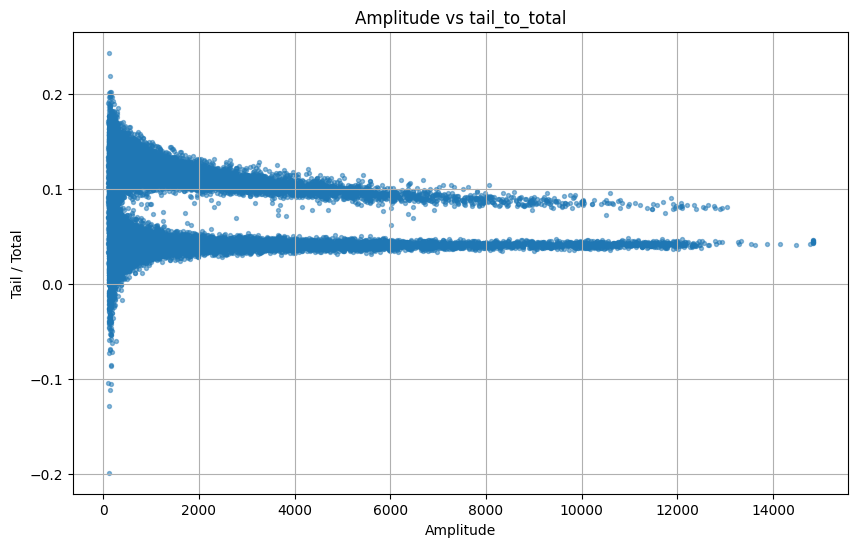

In [27]:
# Анализ зависимости амплитуды от доли хвостовой компоненты

plt.figure(figsize=(10, 6))

plt.scatter(
    features["amplitude"],
    features["tail_to_total"],
    s=8,
    alpha=0.5
)

plt.title("Amplitude vs tail_to_total")
plt.xlabel("Amplitude")
plt.ylabel("Tail / Total")
plt.grid(True)
plt.show()

На графике видно, что сигналы формируют две выраженные области по признаку "tail_to_total".  
Одна группа имеет меньшую долю хвостовой компоненты, другая - большую.

При малых амплитудах наблюдается больший разброс значений "tail_to_total", что может быть связано со слабыми или пограничными сигналами.  
В целом этот график показывает, что отношение хвостовой части к полной площади сигнала является информативным признаком для кластеризации.

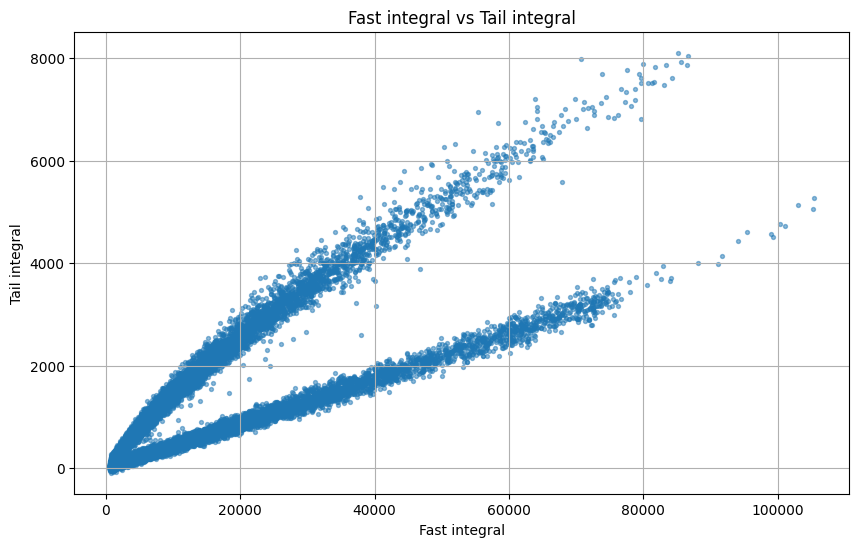

In [28]:
# Анализ быстрой и хвостовой компонент сигнала

plt.figure(figsize=(10, 6))

plt.scatter(
    features["fast_integral"],
    features["tail_integral"],
    s=8,
    alpha=0.5
)

plt.title("Fast integral vs Tail integral")
plt.xlabel("Fast integral")
plt.ylabel("Tail integral")
plt.grid(True)
plt.show()

График "fast_integral vs tail_integral" показывает две хорошо различимые ветви.  
Это означает, что при одинаковой или близкой величине быстрой компоненты сигналы могут иметь разную выраженность хвоста.

Такое разделение хорошо соответствует физической идее PSD-анализа: разные типы частиц могут давать импульсы с различной долей хвостовой компоненты.  
Поэтому признаки, связанные с fast- и tail-интегралами, являются ключевыми для итоговой модели кластеризации.

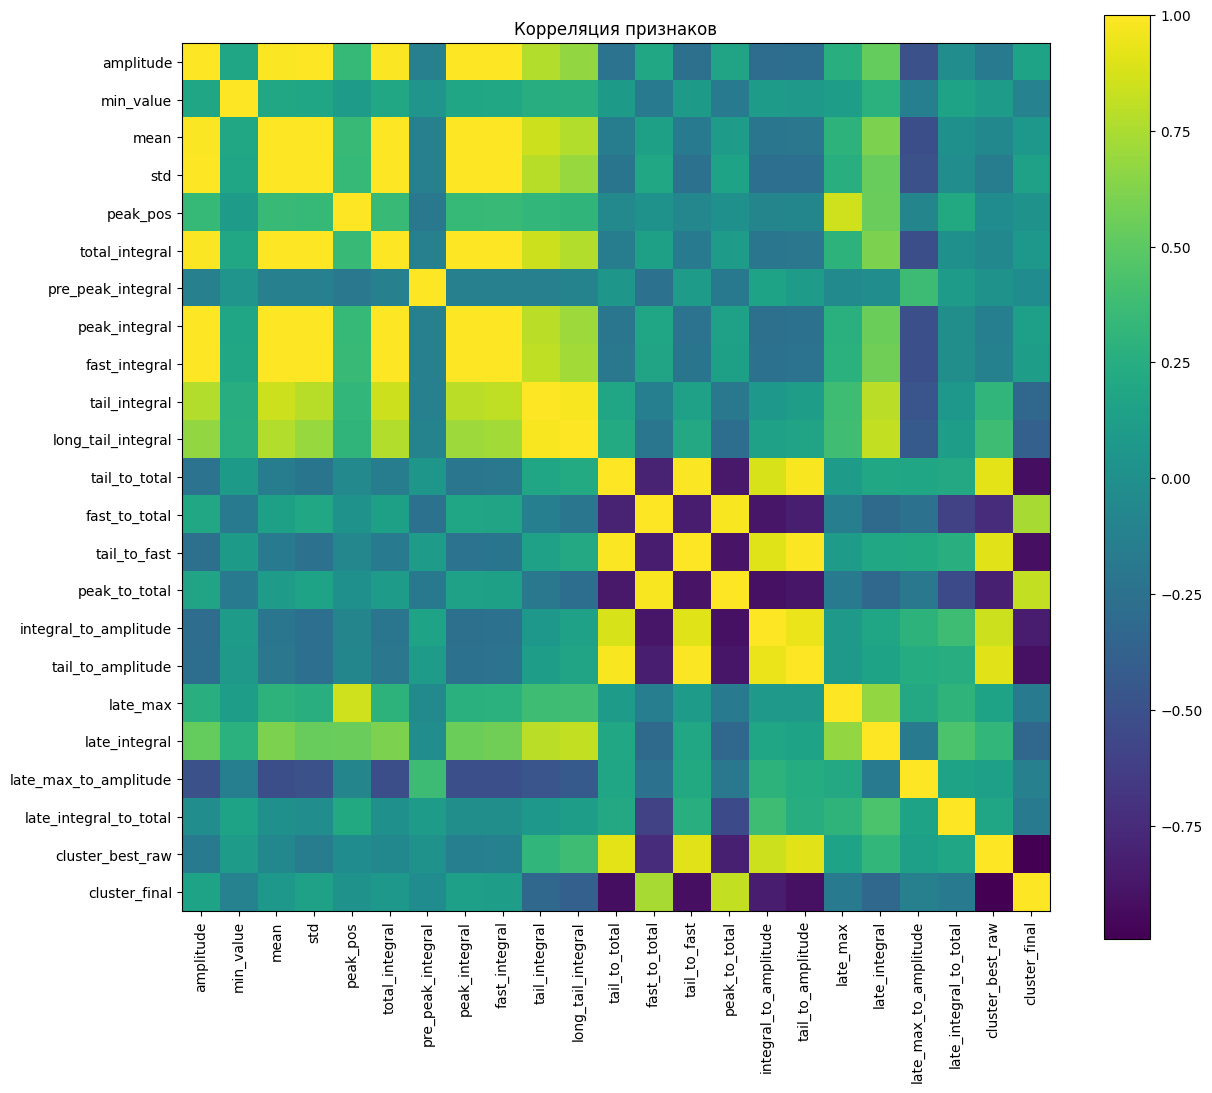

In [29]:
# корреляция признаков

corr = features.corr()

plt.figure(figsize=(14, 12))
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Корреляция признаков")
plt.show()

Корреляционная матрица показывает, что часть признаков сильно связана между собой.  
Например, амплитуда, полная интегральная площадь, интеграл пика и fast-интеграл имеют высокую положительную корреляцию, так как все они описывают общую интенсивность сигнала.

При этом PSD-признаки (tail_to_total, tail_to_fast, integral_to_amplitude) несут дополнительную информацию о форме импульса и не полностью дублируют амплитудные признаки.

## Сравнение моделей

В ходе работы было протестировано несколько подходов к кластеризации сигналов.  
Основные эксперименты вынесены в отдельные ноутбуки, а в финальное решение добавлен лучший вариант.

Были рассмотрены следующие подходы:

1. **KMeans**;
2. **IsolationForest + GMM**;
3. **GMM на расширенном наборе признаков**;
4. **GMM на PSD-признаках**;
5. **Rule-based PSD-подход**.

Модель **KMeans** показала ограниченное качество, так как была склонна разделять сигналы в основном по амплитуде, а не по форме импульса.

Подход **IsolationForest + GMM** позволял выделять аномальные сигналы, однако формировал слишком малый аномальный кластер и хуже отражал общую структуру данных.

**GMM на расширенном наборе признаков** использовал амплитудные, интегральные и PSD-признаки. Однако добавление большого числа признаков не улучшило результат, так как часть признаков была связана между собой.

**GMM на PSD-признаках** показал более хороший и интерпретируемый результат. Эти признаки описывают форму сигнала и соотношение быстрой и хвостовой части импульса.

После дополнительных экспериментов лучший результат показал **rule-based PSD-подход**.  
В этом подходе сначала выделяется небольшое число сигналов с самой маленькой амплитудой, а затем остальные сигналы делятся на две группы по признаку `tail_to_total`.

Финальная модель использует:

- `tail_to_total`;
- оптимизированные окна `145:165` и `165:230`;
- выделение малого weak-класса;
- перенумерацию кластеров для формата Kaggle.

Итоговый public score на Kaggle: `0.84032`.

## Финальная модель

In [16]:
# Финальные PSD-признаки с оптимизированными окнами

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

best_fast_window = (145, 165)
best_tail_window = (165, 230)

fast_start, fast_end = best_fast_window
tail_start, tail_end = best_tail_window

features_window = pd.DataFrame(index=signals_processed.index)

features_window["amplitude"] = signals_processed.max(axis=1)
features_window["total_integral"] = signals_processed.sum(axis=1)
features_window["fast_integral"] = signals_processed.iloc[:, fast_start:fast_end].sum(axis=1)
features_window["tail_integral"] = signals_processed.iloc[:, tail_start:tail_end].sum(axis=1)

eps = 1e-9

features_window["tail_to_total"] = (
    features_window["tail_integral"] / (features_window["total_integral"] + eps)
)

features_window["tail_to_fast"] = (
    features_window["tail_integral"] / (features_window["fast_integral"] + eps)
)

features_window["integral_to_amplitude"] = (
    features_window["total_integral"] / (features_window["amplitude"] + eps)
)

features_window = features_window.replace([np.inf, -np.inf], np.nan)
features_window = features_window.fillna(features_window.median())

print("Размер таблицы финальных признаков:", features_window.shape)
display(features_window.head())

Размер таблицы финальных признаков: (23479, 7)


,amplitude,total_integral,fast_integral,tail_integral,tail_to_total,tail_to_fast,integral_to_amplitude
0,530.13,4614.0,3416.6,758.45,0.164380,0.221990,8.703526
1,1901.47,12348.0,11135.4,748.55,0.060621,0.067223,6.493923
2,2557.92,16955.0,15570.4,832.80,0.049118,0.053486,6.628432
3,564.76,4658.0,3629.2,678.40,0.145642,0.186928,8.247751
4,1793.43,11606.0,10736.6,696.95,0.060051,0.064913,6.471398


Были обновлены признаки с использованием оптимальных окон `145:165` и `165:230`.  
Окно `145:165` используется для расчёта быстрой части сигнала, а окно `165:230` - для расчёта хвостовой части.

На основе этих окон были рассчитаны интегральные признаки `fast_integral` и `tail_integral`, а также относительные PSD-признаки `tail_to_total`, `tail_to_fast` и `integral_to_amplitude`.

В результате была получена финальная таблица признаков размером `(23479, 7)`. Эти признаки дальше используются в итоговом rule-based подходе для разделения сигналов по форме импульса.

### Обучение финального rule-based решения

В финальном варианте отдельный малый кластер формируется из `7` сигналов с минимальной амплитудой. Остальные сигналы делятся на две основные PSD-группы по квантилю `0.494` признака `tail_to_total`.

In [17]:
# Финальная rule-based разметка

best_weak_count = 7
best_psd_q = 0.494

best_rule_mapping = {
    0: 1,
    1: 0,
    2: 2
}

amplitude_values = features_window["amplitude"].values
sorted_by_amplitude = np.argsort(amplitude_values)

weak_mask = np.zeros(len(features_window), dtype=bool)
weak_indices = sorted_by_amplitude[:best_weak_count]
weak_mask[weak_indices] = True

normal_mask = ~weak_mask

best_psd_threshold = features_window.loc[normal_mask, "tail_to_total"].quantile(best_psd_q)

labels_best_raw = np.zeros(len(features_window), dtype=int)

labels_best_raw[
    normal_mask & (features_window["tail_to_total"] <= best_psd_threshold)
] = 0

labels_best_raw[
    normal_mask & (features_window["tail_to_total"] > best_psd_threshold)
] = 1

labels_best_raw[weak_mask] = 2

features["cluster_best_raw"] = labels_best_raw

features["cluster_final"] = (
    pd.Series(labels_best_raw, index=features.index)
    .map(best_rule_mapping)
    .astype(int)
)

print("PSD threshold:", best_psd_threshold)

print("\nРазмеры кластеров до mapping:")
print(features["cluster_best_raw"].value_counts().sort_index())

print("\nРазмеры финальных кластеров после mapping:")
print(features["cluster_final"].value_counts().sort_index())

X_eval = features_window[["tail_to_total", "tail_to_fast", "integral_to_amplitude"]]

print("\nМетрики внутреннего качества кластеризации:")
print("Silhouette:", silhouette_score(X_eval, features["cluster_best_raw"]))
print("Davies-Bouldin:", davies_bouldin_score(X_eval, features["cluster_best_raw"]))
print("Calinski-Harabasz:", calinski_harabasz_score(X_eval, features["cluster_best_raw"]))

PSD threshold: 0.10556615635508816

Размеры кластеров до mapping:
cluster_best_raw
0    11595
1    11877
2        7
Name: count, dtype: int64

Размеры финальных кластеров после mapping:
cluster_final
0    11877
1    11595
2        7
Name: count, dtype: int64

Метрики внутреннего качества кластеризации:
Silhouette: 0.6327517118384817
Davies-Bouldin: 1.4882571820959105
Calinski-Harabasz: 29900.809501212014


Финальная rule-based модель разделила данные на две основные группы и один очень маленький класс.  
Основные кластеры получились почти равными по размеру: 11 877 и 11 595 сигналов.  
В отдельный класс было выделено 7 сигналов с самой маленькой амплитудой.

Порог по признаку `tail_to_total` составил `0.10557`. Именно по этому порогу основная часть сигналов была разделена на две группы.

Метрика Silhouette равна `0.633`, что указывает на достаточно хорошее разделение кластеров.  
Davies-Bouldin равен `1.488`, а Calinski-Harabasz - `29900.81`, что также подтверждает наличие выраженной структуры в данных.

Полученное решение является простым и интерпретируемым: оно учитывает форму сигнала и отдельно обрабатывает самые слабые импульсы.

### Визуализация финальных кластеров

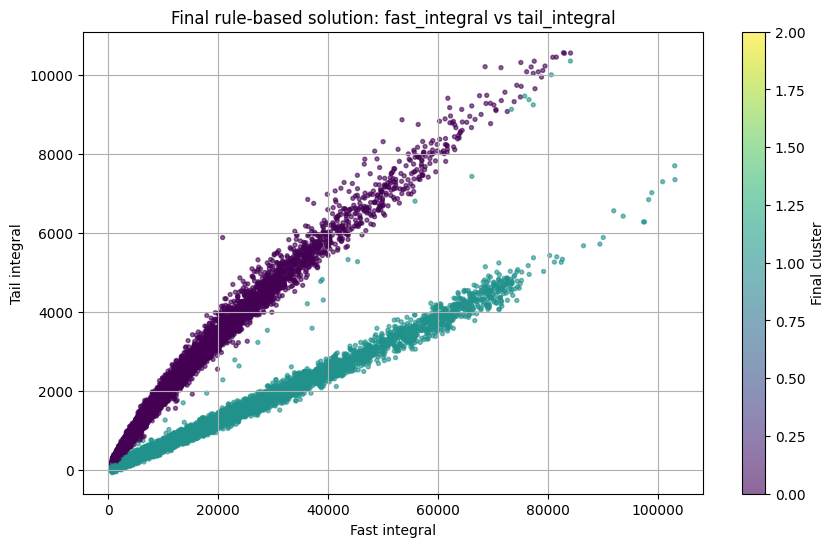

In [18]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features_window["fast_integral"],
    features_window["tail_integral"],
    c=features["cluster_final"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.title("Final rule-based solution: fast_integral vs tail_integral")
plt.xlabel("Fast integral")
plt.ylabel("Tail integral")
plt.grid(True)
plt.colorbar(label="Final cluster")
plt.show()

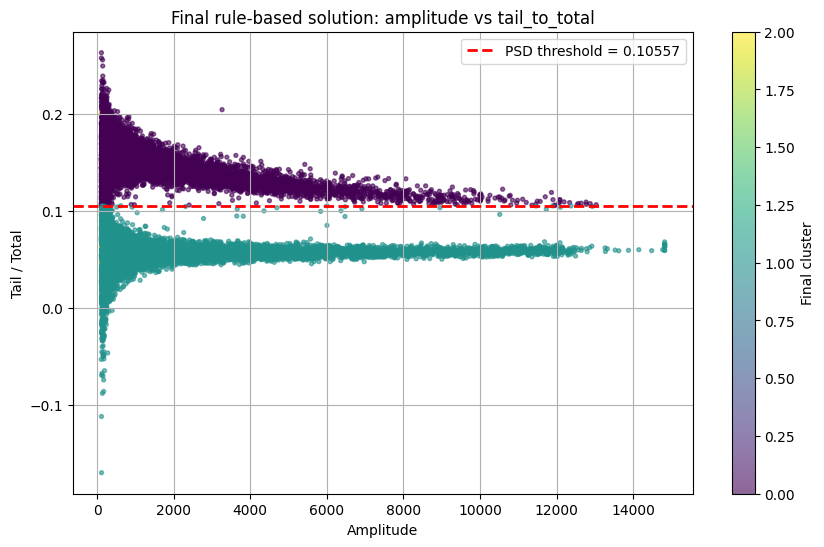

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(
    features_window["amplitude"],
    features_window["tail_to_total"],
    c=features["cluster_final"],
    s=8,
    alpha=0.6,
    cmap="viridis"
)

plt.axhline(
    best_psd_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"PSD threshold = {best_psd_threshold:.5f}"
)

plt.title("Final rule-based solution: amplitude vs tail_to_total")
plt.xlabel("Amplitude")
plt.ylabel("Tail / Total")
plt.grid(True)
plt.legend()
plt.colorbar(label="Final cluster")
plt.show()

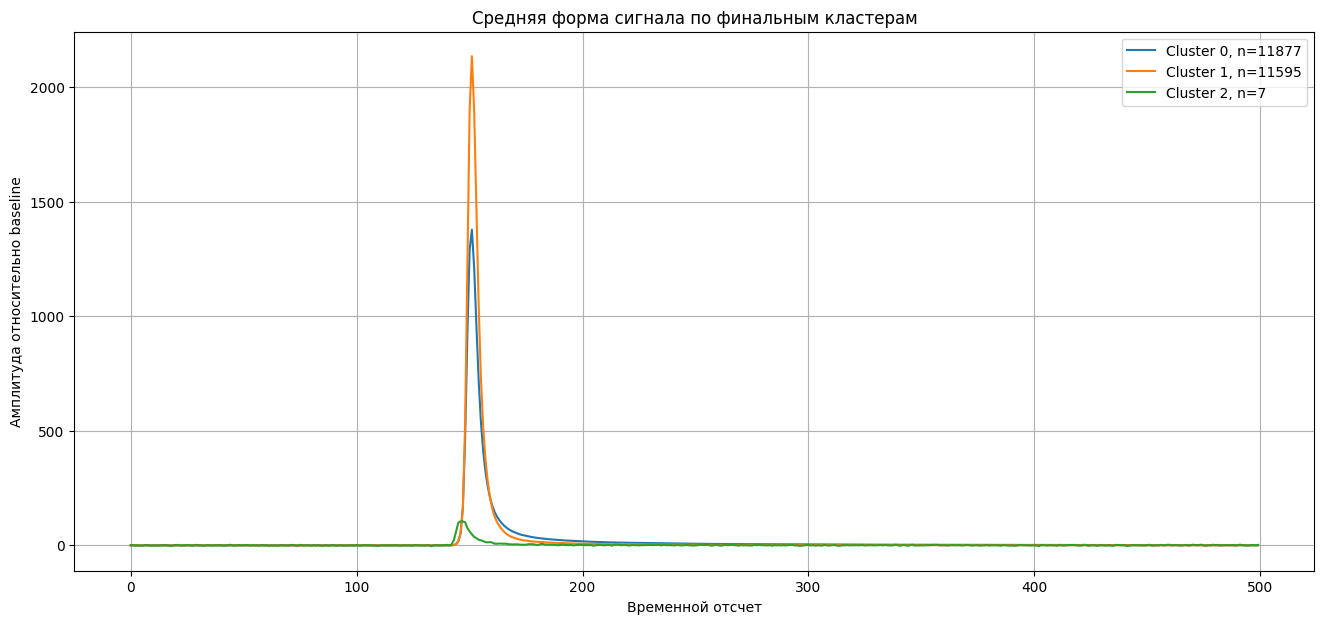

In [20]:
plt.figure(figsize=(16, 7))

for cluster in sorted(features["cluster_final"].unique()):
    cluster_indices = features.index[features["cluster_final"] == cluster]
    mean_cluster_signal = signals_processed.loc[cluster_indices].mean(axis=0)

    plt.plot(
        x_axis,
        mean_cluster_signal.values,
        label=f"Cluster {cluster}, n={len(cluster_indices)}"
    )

plt.title("Средняя форма сигнала по финальным кластерам")
plt.xlabel("Временной отсчет")
plt.ylabel("Амплитуда относительно baseline")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
cluster_summary_final = features_window.groupby(features["cluster_final"])[[
    "amplitude",
    "total_integral",
    "fast_integral",
    "tail_integral",
    "tail_to_total",
    "tail_to_fast",
    "integral_to_amplitude"
]].median()

display(cluster_summary_final)

,amplitude,total_integral,fast_integral,tail_integral,tail_to_total,tail_to_fast,integral_to_amplitude
cluster_final,,,,,,,
0,740.16,6782.0,5169.4,1068.70,0.148749,0.193029,8.907272
1,890.51,5656.0,5231.0,327.05,0.056957,0.061912,6.367160
2,106.29,1242.0,818.8,123.90,0.099758,0.135232,11.536318


Две основные группы хорошо различаются по доле хвостовой части сигнала: это видно как на графике "amplitude vs tail_to_total", так и на графике "fast_integral vs tail_integral".

Малый класс из 7 объектов содержит самые слабые сигналы с минимальной амплитудой и низкими интегральными значениями, поэтому он почти не заметен на общих графиках.


### Формирование финального submission

In [22]:
# Формирование submission

submission_final = pd.DataFrame({
    "index": features.index,
    "cluster": features["cluster_final"].values
})

print("Размер submission:", submission_final.shape)
print("Распределение финальных кластеров:")
print(submission_final["cluster"].value_counts().sort_index())

display(submission_final.head())
display(submission_final.tail())

submission_final.to_csv("submission_final.csv", index=False)

Размер submission: (23479, 2)
Распределение финальных кластеров:
cluster
0    11877
1    11595
2        7
Name: count, dtype: int64


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


,index,cluster
23474,23474,1
23475,23475,0
23476,23476,0
23477,23477,0
23478,23478,1


In [23]:
# Проверка формата итогового файла
assert submission_final.shape == (23479, 2)
assert list(submission_final.columns) == ["index", "cluster"]
assert set(submission_final["cluster"].unique()).issubset({0, 1, 2})
assert submission_final["index"].is_monotonic_increasing

print("Файл submission_final.csv успешно сформирован.")

Файл submission_final.csv успешно сформирован.


In [25]:
from google.colab import files
files.download("submission_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>